# Telecom Churn Prediction – Model Comparison and Selection

Goals:
- Load the trained baseline models.
- Evaluate models on the test dataset.
- Compare model performance using key metrics.
- Visualize results (ROC curves, confusion matrices).
- Select the best performing model for deployment.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

import joblib
sns.set_style("whitegrid")

In [22]:
df = pd.read_csv("../../data/processed/telecom_churn_clean.csv")

df.head()

,tenure,MonthlyCharges,Churn,num_services,gender_Male,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,charge_level_medium,charge_level_high,tenure_group_early,tenure_group_established,tenure_group_loyal
0,-1.277445,-1.160323,0,-0.561776,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
1,0.066327,-0.259629,0,-0.020519,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False
2,-1.236724,-0.362660,1,-0.020519,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False
3,0.514251,-0.746535,0,0.520738,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
4,-1.236724,0.197365,1,-1.103033,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,False


In [23]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
log_model = joblib.load("../models/logistic_regression_baseline.pkl")

rf_model = joblib.load("../models/random_forest_baseline.pkl")

In [26]:
#Generate Predictions

# Compatibility fix for models loaded from older/newer sklearn versions
if not hasattr(log_model, "multi_class"):
	log_model.multi_class = "auto"

# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [27]:
#Evaluate Model Performance
results = []

models = {
    "Logistic Regression": (log_pred, log_prob),
    "Random Forest": (rf_pred, rf_prob)
}

for name, (pred, prob) in models.items():
    
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.735273,0.500861,0.778075,0.609424,0.840945
1,Random Forest,0.760114,0.533962,0.756684,0.626106,0.842427


In [28]:
#Sort Models by Performance
results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.760114,0.533962,0.756684,0.626106,0.842427
0,Logistic Regression,0.735273,0.500861,0.778075,0.609424,0.840945


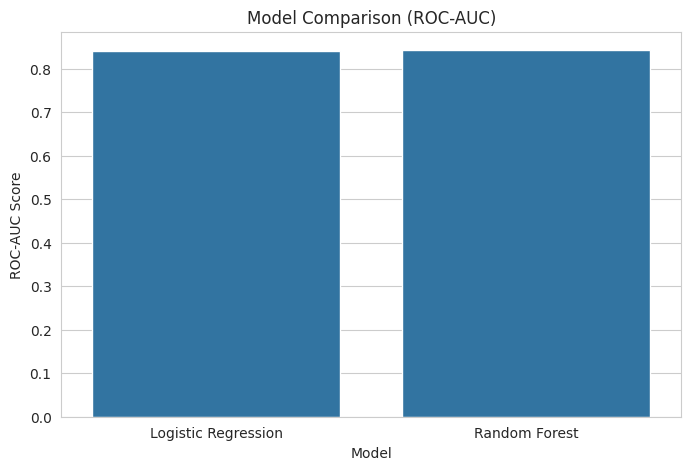

In [29]:
#Visualize Model Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="ROC AUC",
    data=results_df
)

plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC Score")
plt.xlabel("Model")

plt.show()

<Figure size 700x500 with 0 Axes>

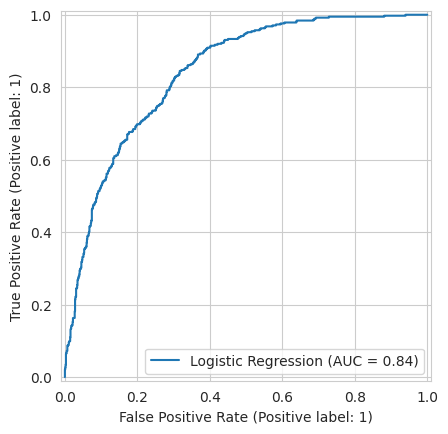

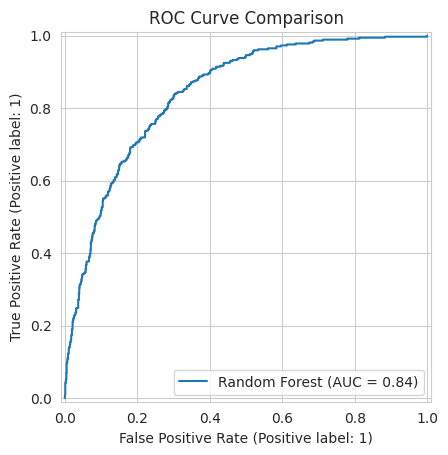

In [30]:
#plot RUC curve

plt.figure(figsize=(7,5))

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")

plt.show()

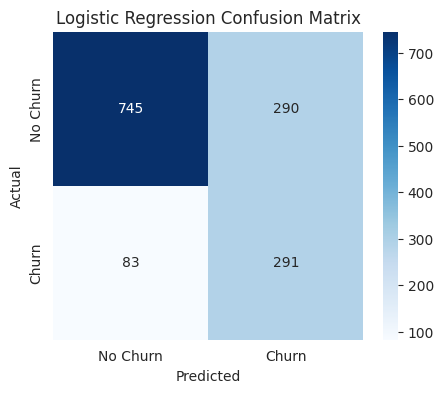

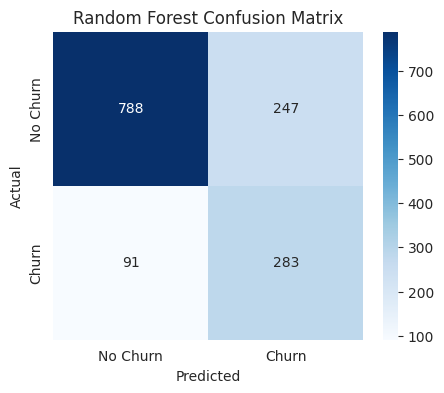

In [31]:
#Confusion Matrices
models_predictions = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred
}

for name, pred in models_predictions.items():

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [32]:
#Select the Best Model
best_model_name = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]["Model"]

best_model_name

'Random Forest'

In [33]:
#Save the Final Model
if best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = log_model

joblib.dump(best_model, "../models/final_model.pkl")

['../models/final_model.pkl']

## Model Comparison Summary

Two baseline models were evaluated:

- Logistic Regression
- Random Forest

Evaluation metrics used:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best model was selected based on **ROC-AUC**, which is a suitable metric for churn prediction problems.

The selected model was saved as `final_model.pkl` for future use.

Next Steps:
- Perform hyperparameter tuning to improve performance.
- Conduct cross-validation for robustness.
- Prepare the model for deployment.